In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hour = pd.read_csv("hour.csv")
day = pd.read_csv("day.csv")

In [15]:
hour = hour.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
day = day.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
print("Hour dataset after dropping columns:")
print(hour.head().to_string(index=False))

print("\nDay dataset after dropping columns:")
print(day.head().to_string(index=False))


Hour dataset after dropping columns:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1

Day dataset after dropping columns:
 season  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  cnt
      1     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446  985
      1     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539  801
      1     1        0        1           1           1 0.196364 

In [25]:
hour.isnull().sum()



season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [27]:
day.isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [26]:
hour_duplicates = hour.duplicated().sum()
day_duplicates = day.duplicated().sum()
print("Number of duplicate hours:", hour_duplicates)
print("Number of duplicate days:", day_duplicates)




Number of duplicate hours: 2
Number of duplicate days: 0


In [51]:
hour = hour.drop_duplicates() 
print("Hour dataset after dropping duplicates:")
print(hour.head().to_string(index=False))


Hour dataset after dropping duplicates:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1


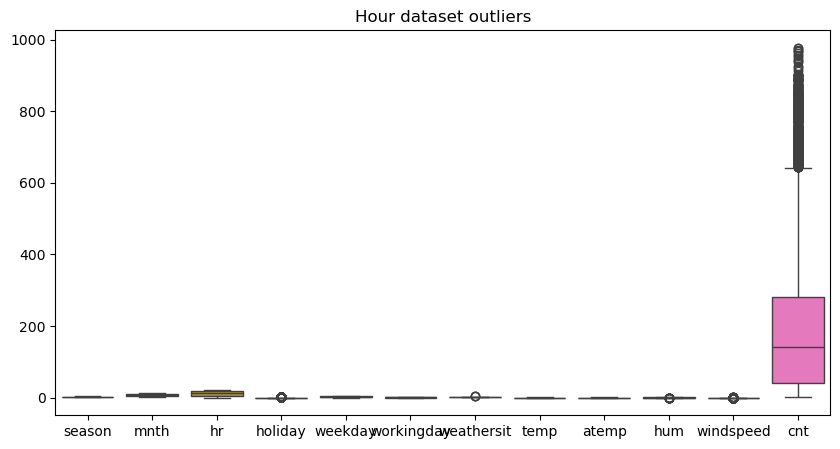

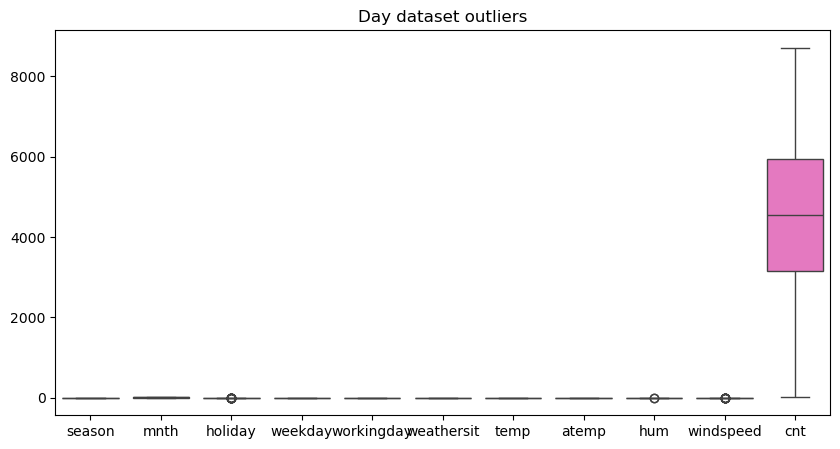

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour)
plt.title("Hour dataset outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=day)
plt.title("Day dataset outliers")
plt.show()


In [35]:
# ---- Outlier Detection for Hour Data ----
Q1_hr = hour.quantile(0.25)
Q3_hr = hour.quantile(0.75)
IQR_hr = Q3_hr - Q1_hr

lower_limit_hr = Q1_hr - 1.5 * IQR_hr
upper_limit_hr = Q3_hr + 1.5 * IQR_hr

hour_cleaned = hour[~((hour < lower_limit_hr) | (hour > upper_limit_hr)).any(axis=1)]

print("Original Hour Shape:", hour.shape)
print("After Removing Outliers:", hour_cleaned.shape)

Original Hour Shape: (17379, 12)
After Removing Outliers: (16029, 12)


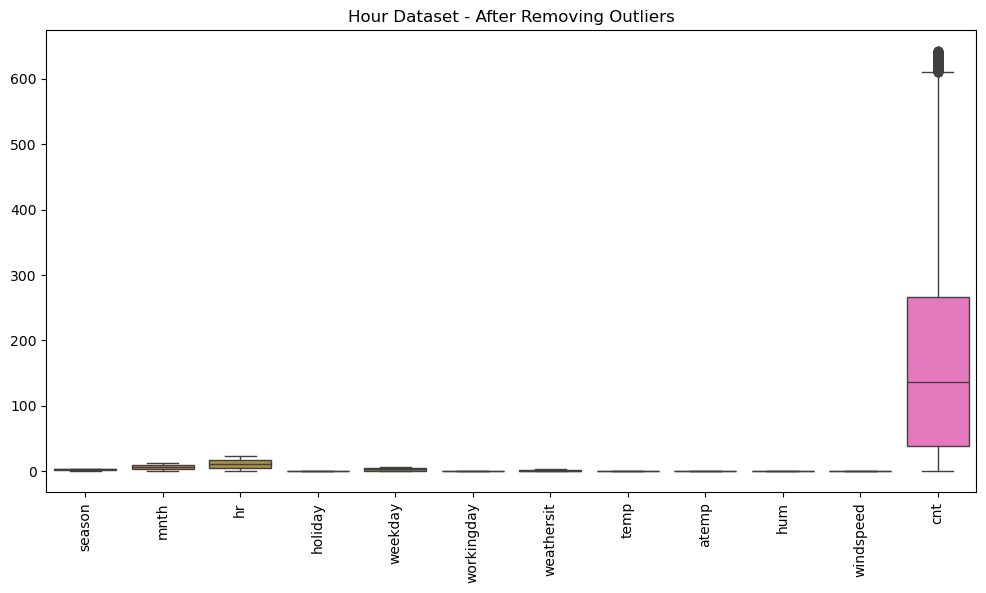

In [36]:
# ---- Boxplot after removing outliers ----
plt.figure(figsize=(12,6))
sns.boxplot(data=hour_cleaned)
plt.title("Hour Dataset - After Removing Outliers")
plt.xticks(rotation=90)
plt.show()

In [37]:
# ---- Outlier Detection for Day Data ----
Q1 = day.quantile(0.25)
Q3 = day.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

day_cleaned = day[~((day < lower_limit) | (day > upper_limit)).any(axis=1)]
print("Original Day Shape:", day.shape)
print("After Removing Outliers:", day_cleaned.shape)



Original Day Shape: (731, 11)
After Removing Outliers: (696, 11)


In [38]:
X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]

X_day = day.drop("cnt", axis=1)
y_day = day["cnt"]

In [43]:
from sklearn.model_selection import train_test_split

# Hourly data train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
# Daily data train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

In [44]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_evaluate_rf(X_train, X_test, y_train, y_test, dataset_name="Dataset"):
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
     
    print(f"{dataset_name} - Random Forest Metrics")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")
    return rf 
    

In [41]:
#Train & evaluate for both datasets
rf_hour = train_evaluate_rf(X_train_hr, X_test_hr, y_train_hr, y_test_hr, "Hourly Data")
rf_day  = train_evaluate_rf(X_train_day, X_test_day, y_train_day, y_test_day, "Daily Data")


Hourly Data - Random Forest Metrics
MAE: 42.22, RMSE: 65.21, R²: 0.87

Daily Data - Random Forest Metrics
MAE: 1083.93, RMSE: 1305.34, R²: 0.58



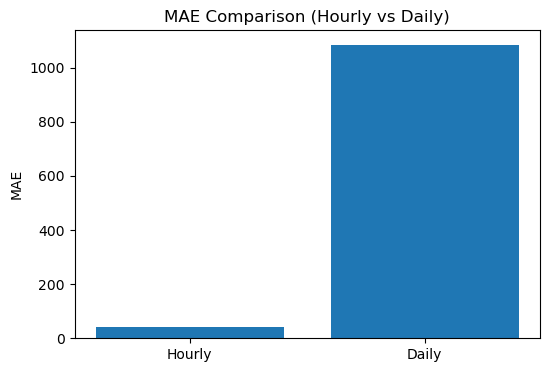

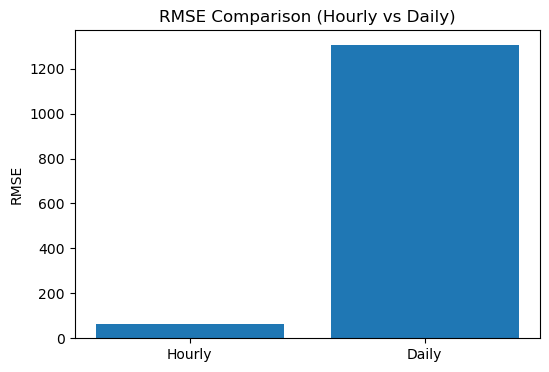

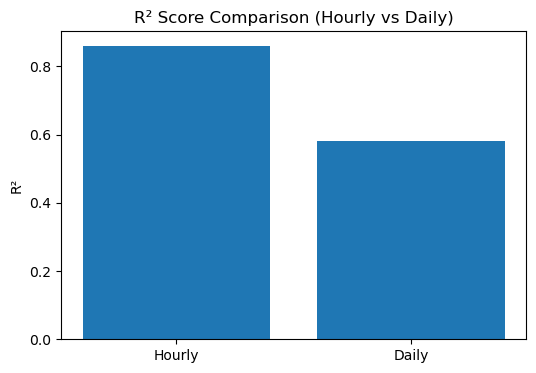

In [50]:
# ---- Metrics Comparison Graphs ----
import matplotlib.pyplot as plt


# MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, mae_values)
plt.title("MAE Comparison (Hourly vs Daily)")
plt.ylabel("MAE")
plt.show()

# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, rmse_values)
plt.title("RMSE Comparison (Hourly vs Daily)")
plt.ylabel("RMSE")
plt.show()

# R² Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, r2_values)
plt.title("R² Score Comparison (Hourly vs Daily)")
plt.ylabel("R²")
plt.show()


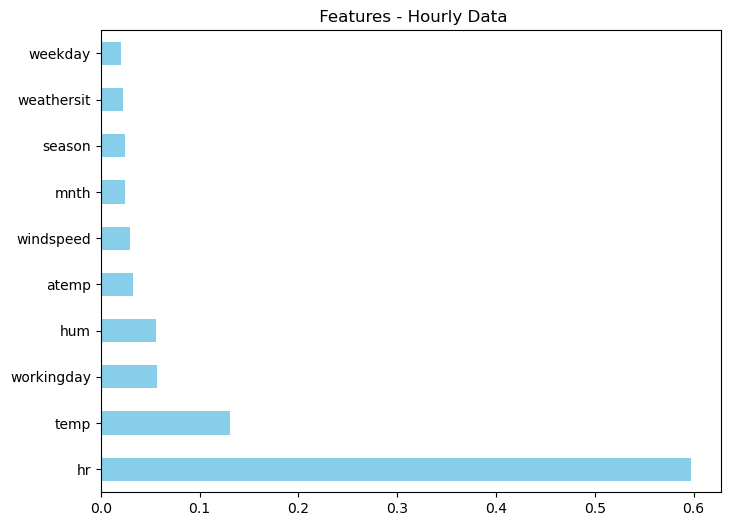

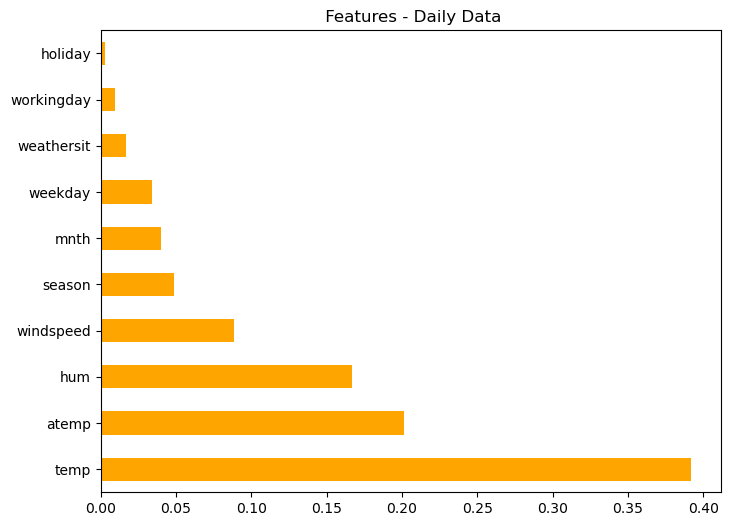

In [42]:
               # --- Feature Importance Plot ---
def plot_feature_importance(rf_model, X_train, dataset_name):
    feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    plt.figure(figsize=(8,6))
    color = 'skyblue' if dataset_name=="Hourly Data" else 'orange'
    feat_importances.nlargest(10).plot(kind='barh', color=color)
    plt.title(f" Features - {dataset_name}")
    plt.show()

# Plot top 10 features for both datasets
plot_feature_importance(rf_hour, X_train_hr, "Hourly Data")
plot_feature_importance(rf_day, X_train_day, "Daily Data")